In [ ]:
import pandas as pd
import numpy as np

def run_backtest(file_path, initial_capital=100000, signal_col='composite_direction', split_filter=None):
    # 1. โหลดข้อมูล
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    # ถ้าต้องการ Backtest เฉพาะ test set ให้ระบุ split_filter='test'
    if split_filter:
        df = df[df['split'] == split_filter].copy()
    
    # 2. จำลองการเทรด (คำนวณ Strategy Return)
    # สมมติว่า actual_return มีหน่วยเป็น % (เช่น 1.23 หมายถึง 1.23%)
    df['strategy_return'] = df[signal_col] * df['actual_return']
    
    # คำนวณ Equity Curve แบบทบต้น (Compounding)
    df['equity_curve'] = initial_capital * (1 + df['strategy_return'] / 100).cumprod()
    
    # 3. คำนวณ Metrics ต่างๆ
    
    # หา Trade ที่เกิดขึ้นจริง (วันที่มี return ไม่เป็น 0 จากการเข้า Position)
    trades = df[df[signal_col] != 0].copy()
    winning_trades = trades[trades['strategy_return'] > 0]
    losing_trades = trades[trades['strategy_return'] < 0]
    
    total_trades = len(trades)
    buy_trades = len(trades[trades[signal_col] == 1])
    sell_trades = len(trades[trades[signal_col] == -1])
    
    win_rate = (len(winning_trades) / total_trades * 100) if total_trades > 0 else 0
    
    avg_win = winning_trades['strategy_return'].mean() if not winning_trades.empty else 0
    avg_loss = losing_trades['strategy_return'].mean() if not losing_trades.empty else 0
    
    gross_profit = winning_trades['strategy_return'].sum()
    gross_loss = abs(losing_trades['strategy_return'].sum())
    profit_factor = (gross_profit / gross_loss) if gross_loss != 0 else np.nan
    
    # Return & Equity
    final_equity = df['equity_curve'].iloc[-1]
    total_return_pct = ((final_equity / initial_capital) - 1) * 100
    
    # Max Drawdown
    df['peak'] = df['equity_curve'].cummax()
    df['drawdown'] = (df['equity_curve'] - df['peak']) / df['peak'] * 100
    max_drawdown = df['drawdown'].min()
    
    # Sharpe Ratio (สมมติว่าเทรด 252 วันต่อปี และ risk-free rate = 0)
    daily_returns = df['strategy_return'] / 100
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() != 0 else 0
    
    # Calmar Ratio (Annualized Return / Max Drawdown)
    days_in_backtest = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days
    annualized_return = ((final_equity / initial_capital) ** (365.25 / days_in_backtest) - 1) * 100
    calmar_ratio = (annualized_return / abs(max_drawdown)) if max_drawdown != 0 else np.nan

    # 4. แสดงผลลัพธ์
    print("="*40)
    print("Backtest Performance Summary")
    print("="*40)
    print(f"  Total Return (%)         : {total_return_pct:.2f}")
    print(f"  Final Equity ($)         : {final_equity:.2f}")
    print(f"  Total Trades             : {total_trades}")
    print(f"  Win Rate (%)             : {win_rate:.2f}")
    print(f"  Avg Win (%)              : {avg_win:.4f}")
    print(f"  Avg Loss (%)             : {avg_loss:.4f}")
    print(f"  Profit Factor            : {profit_factor:.4f}")
    print(f"  Max Drawdown (%)         : {max_drawdown:.2f}")
    print(f"  Sharpe Ratio             : {sharpe_ratio:.4f}")
    print(f"  Calmar Ratio             : {calmar_ratio:.4f}")
    print(f"  BUY trades               : {buy_trades}")
    print(f"  SELL trades              : {sell_trades}")
    print("="*40)
    
    return df

# สมมติต้นทุนเริ่มต้นที่ $100,000 
result_df = run_backtest('../data/processed/predictions/combined_predictions_full.csv', initial_capital=100000)



 📈 Backtest Performance Summary
  Total Return (%)         : 143.60
  Final Equity ($)         : 243603.37
  Total Trades             : 157
  Win Rate (%)             : 87.90
  Avg Win (%)              : 0.6807
  Avg Loss (%)             : -0.4370
  Profit Factor            : 21.4952
  Max Drawdown (%)         : -1.49
  Sharpe Ratio             : 2.7672
  Calmar Ratio             : 6.1654
  BUY trades               : 90
  SELL trades              : 67


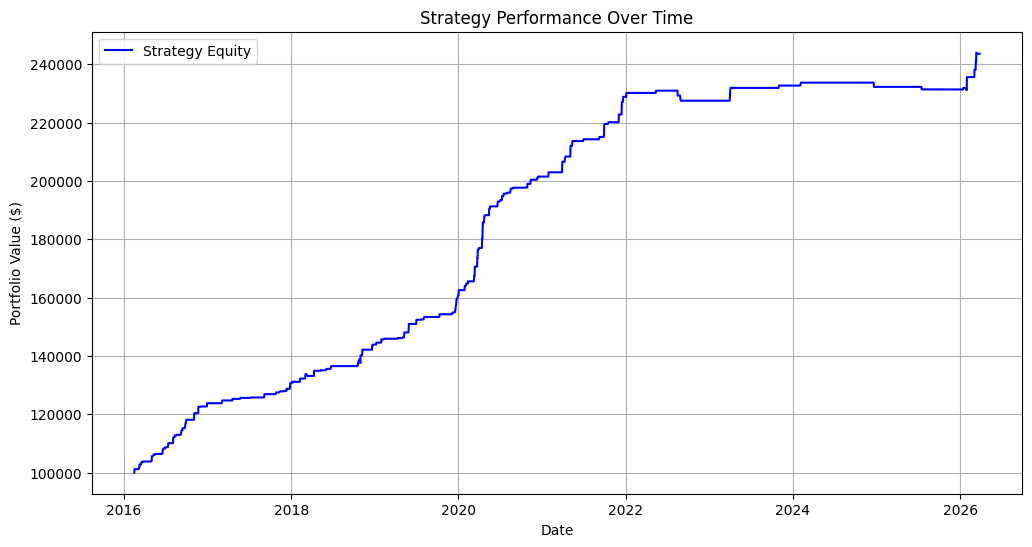

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(result_df['Date'], result_df['equity_curve'], label='Strategy Equity', color='blue')
plt.title('Strategy Performance Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
def show_latest_prediction(df):
    # ดึงข้อมูลแถวสุดท้าย (วันล่าสุดในระบบ)
    latest_data = df.iloc[-1]
    
    # ดึงวันที่
    # หาก Date เป็น datetime object ให้แปลงเป็น string เพื่อความสวยงาม
    date_str = latest_data['Date'].strftime('%Y-%m-%d') if isinstance(latest_data['Date'], pd.Timestamp) else latest_data['Date']
    
    # ฝั่ง Regression: ดึงค่าที่ทำนายว่ากี่ % (ใช้ pred_ensemble หรือ pred_magnitude)
    reg_pred_pct = latest_data['pred_ensemble']
    
    #  ฝั่ง Classification: ดึงค่า Signal (1, 0, -1)
    cls_signal_num = latest_data['pred_direction_cls']
    
    # สัญญาณสุทธิ (เผื่อต้องการดูว่า 2 โมเดลตกลงกันแล้วได้ผลลัพธ์เป็นอะไร)
    composite_signal_num = latest_data['composite_direction']
    
    # Map ตัวเลขเป็นข้อความ
    signal_map = {
        1: " BUY (คาดว่าราคาจะขึ้น)", 
        -1: " SELL (คาดว่าราคาจะลง)", 
        0: " HOLD (รอดูสถานการณ์ / ทรงตัว)"
    }
    
    cls_text = signal_map.get(cls_signal_num, "UNKNOWN")
    composite_text = signal_map.get(composite_signal_num, "UNKNOWN")
    
    print("\n" + "="*50)
    print(f" วันที่ทำนายล่าสุด (Latest Prediction): {date_str}")
    print("="*50)
    print(f" Regression Predict (คาดการณ์ผลตอบแทน) : {reg_pred_pct:.4f} %")
    print(f" Classification Signal (สัญญาณดิบ)     : {cls_text}")
    print("-" * 50)
    print(f" Final Composite Signal (สัญญาณเทรดจริง) : {composite_text}")
    print("="*50 + "\n")

# ==========================================
# วิธีการเรียกใช้งาน (นำไปต่อท้ายโค้ดเดิมได้เลย)
# ==========================================
# 1. รัน Backtest และเก็บ DataFrame ไว้ในตัวแปร result_df
result_df = run_backtest('../data/processed/predictions/combined_predictions_full.csv', initial_capital=100000)

# 2. เรียกฟังก์ชันแสดงผลวันล่าสุด
show_latest_prediction(result_df)

 📈 Backtest Performance Summary
  Total Return (%)         : 143.60
  Final Equity ($)         : 243603.37
  Total Trades             : 157
  Win Rate (%)             : 87.90
  Avg Win (%)              : 0.6807
  Avg Loss (%)             : -0.4370
  Profit Factor            : 21.4952
  Max Drawdown (%)         : -1.49
  Sharpe Ratio             : 2.7672
  Calmar Ratio             : 6.1654
  BUY trades               : 90
  SELL trades              : 67

 วันที่ทำนายล่าสุด (Latest Prediction): 2026-03-27
 Regression Predict (คาดการณ์ผลตอบแทน) : -0.0502 %
 Classification Signal (สัญญาณดิบ)     :  SELL (คาดว่าราคาจะลง)
--------------------------------------------------
 Final Composite Signal (สัญญาณเทรดจริง) :  HOLD (รอดูสถานการณ์ / ทรงตัว)



In [9]:
# รันเฉพาะช่วง Train Set 
result_train_df = run_backtest('../data/processed/predictions/combined_predictions_full.csv', initial_capital=100000, split_filter='train')

 📈 Backtest Performance Summary
  Total Return (%)         : 128.83
  Final Equity ($)         : 228830.01
  Total Trades             : 137
  Win Rate (%)             : 93.43
  Avg Win (%)              : 0.6613
  Avg Loss (%)             : -0.4701
  Profit Factor            : 60.0281
  Max Drawdown (%)         : -0.84
  Sharpe Ratio             : 3.6604
  Calmar Ratio             : 17.9685
  BUY trades               : 80
  SELL trades              : 57


In [10]:
# รันเฉพาะช่วง Test Set 
result_train_df = run_backtest('../data/processed/predictions/combined_predictions_full.csv', initial_capital=100000, split_filter='test')

 📈 Backtest Performance Summary
  Total Return (%)         : 4.69
  Final Equity ($)         : 104693.00
  Total Trades             : 14
  Win Rate (%)             : 42.86
  Avg Win (%)              : 1.0151
  Avg Loss (%)             : -0.2922
  Profit Factor            : 4.1691
  Max Drawdown (%)         : -1.10
  Sharpe Ratio             : 1.0490
  Calmar Ratio             : 1.8848
  BUY trades               : 4
  SELL trades              : 10
